In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor

In [2]:
training_df = pd.read_csv("../datasets/training.csv")
training_df.set_index("date", inplace=True)

X_train = training_df.iloc[:,1:]
y_train = training_df.Appliances
training_df

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint
date,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,60,30,19.890000,47.596667,19.200000,44.790000,19.790000,44.730000,19.00,45.566667,...,18.2000,48.900000,17.033333,45.530000,6.600000,733.5,92.000000,7.000000,63.000000,5.300000
2016-01-11 17:10:00,60,30,19.890000,46.693333,19.200000,44.722500,19.790000,44.790000,19.00,45.992500,...,18.2000,48.863333,17.066667,45.560000,6.483333,733.6,92.000000,6.666667,59.166667,5.200000
2016-01-11 17:30:00,50,40,19.890000,46.066667,19.200000,44.590000,19.790000,45.000000,18.89,45.723333,...,18.1000,48.590000,17.000000,45.400000,6.250000,733.8,92.000000,6.000000,51.500000,5.000000
2016-01-11 17:40:00,60,40,19.890000,46.333333,19.200000,44.530000,19.790000,45.000000,18.89,45.530000,...,18.1000,48.590000,17.000000,45.400000,6.133333,733.9,92.000000,5.666667,47.666667,4.900000
2016-01-11 17:50:00,50,40,19.890000,46.026667,19.200000,44.500000,19.790000,44.933333,18.89,45.730000,...,18.1000,48.590000,17.000000,45.290000,6.016667,734.0,92.000000,5.333333,43.833333,4.800000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-05-27 17:00:00,110,0,25.600000,47.193333,25.968571,42.528571,27.390000,41.030000,24.70,45.626667,...,24.6000,50.863333,23.200000,46.751429,23.000000,755.2,55.000000,3.000000,22.000000,13.400000
2016-05-27 17:20:00,100,0,25.566667,46.560000,25.890000,42.025714,27.200000,41.163333,24.70,45.590000,...,24.7000,50.074000,23.200000,46.790000,22.733333,755.2,55.666667,3.333333,23.666667,13.333333
2016-05-27 17:30:00,90,0,25.500000,46.500000,25.754000,42.080000,27.133333,41.223333,24.70,45.590000,...,24.7000,49.790000,23.200000,46.790000,22.600000,755.2,56.000000,3.500000,24.500000,13.300000


In [3]:
testing_df = pd.read_csv("../datasets/testing.csv")
testing_df.set_index("date", inplace=True)
X_test = testing_df.iloc[:, 1:]
y_test = testing_df.Appliances
testing_df

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint
date,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:20:00,50,30,19.890000,46.300000,19.200000,44.626667,19.790000,44.933333,18.926667,45.890000,...,18.200000,48.730000,17.000000,45.500000,6.366667,733.700000,92.000000,6.333333,55.333333,5.100000
2016-01-11 18:50:00,580,60,20.066667,46.396667,19.426667,44.400000,19.790000,44.826667,19.000000,46.430000,...,18.066667,48.633333,16.890000,45.290000,5.983333,734.433333,91.166667,5.833333,40.000000,4.616667
2016-01-11 19:00:00,430,50,20.133333,48.000000,19.566667,44.400000,19.890000,44.900000,19.000000,46.363333,...,18.066667,48.560000,16.963333,45.290000,6.000000,734.500000,91.000000,6.000000,40.000000,4.600000
2016-01-11 19:10:00,250,40,20.260000,52.726667,19.730000,45.100000,19.890000,45.493333,19.000000,47.223333,...,18.033333,48.666667,16.890000,45.326667,6.000000,734.616667,90.500000,6.000000,40.000000,4.516667
2016-01-11 19:30:00,100,10,20.566667,53.893333,20.033333,46.756667,20.100000,48.466667,19.000000,48.490000,...,18.150000,49.200000,16.890000,45.326667,6.000000,734.850000,89.500000,6.000000,40.000000,4.350000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-05-27 15:00:00,60,0,25.500000,45.933333,26.277143,41.000000,28.356667,40.560000,24.666667,45.400000,...,23.963333,49.000000,23.100000,46.590000,21.800000,755.800000,59.000000,2.000000,21.000000,13.300000
2016-05-27 15:30:00,80,0,25.500000,45.590000,26.100000,41.000000,28.200000,40.126667,24.700000,45.163333,...,24.000000,48.790000,23.166667,46.590000,22.300000,755.650000,57.000000,2.000000,22.000000,13.250000
2016-05-27 16:30:00,220,0,25.426667,46.060000,26.000000,41.700000,28.000000,40.760000,24.700000,45.400000,...,24.356667,51.333333,23.200000,46.700000,22.900000,755.350000,55.000000,2.500000,22.500000,13.300000


# Number of Trees

In [13]:
n_trees   = range(1, 300, 3)
rmse_list = []
for n in n_trees:
    model = RandomForestRegressor(n_estimators=n, max_features=18, n_jobs=-1, verbose=1, random_state=1337)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_list.append(rmse)
    print("   -> RMSE:", rmse)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


   -> RMSE: 99.92741589527418


[Parallel(n_jobs=-1)]: Done   4 out of   4 | elapsed:    0.3s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   2 out of   4 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=4)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


   -> RMSE: 79.76245387038956


[Parallel(n_jobs=-1)]: Done   7 out of   7 | elapsed:    0.3s finished
[Parallel(n_jobs=7)]: Using backend ThreadingBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done   2 out of   7 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=7)]: Done   7 out of   7 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


...

[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    4.7s
[Parallel(n_jobs=-1)]: Done 295 out of 295 | elapsed:    7.7s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 295 out of 295 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


   -> RMSE: 69.15889580561696


[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    4.7s


   -> RMSE: 69.13604353387386


[Parallel(n_jobs=-1)]: Done 298 out of 298 | elapsed:    7.9s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 298 out of 298 | elapsed:    0.1s finished


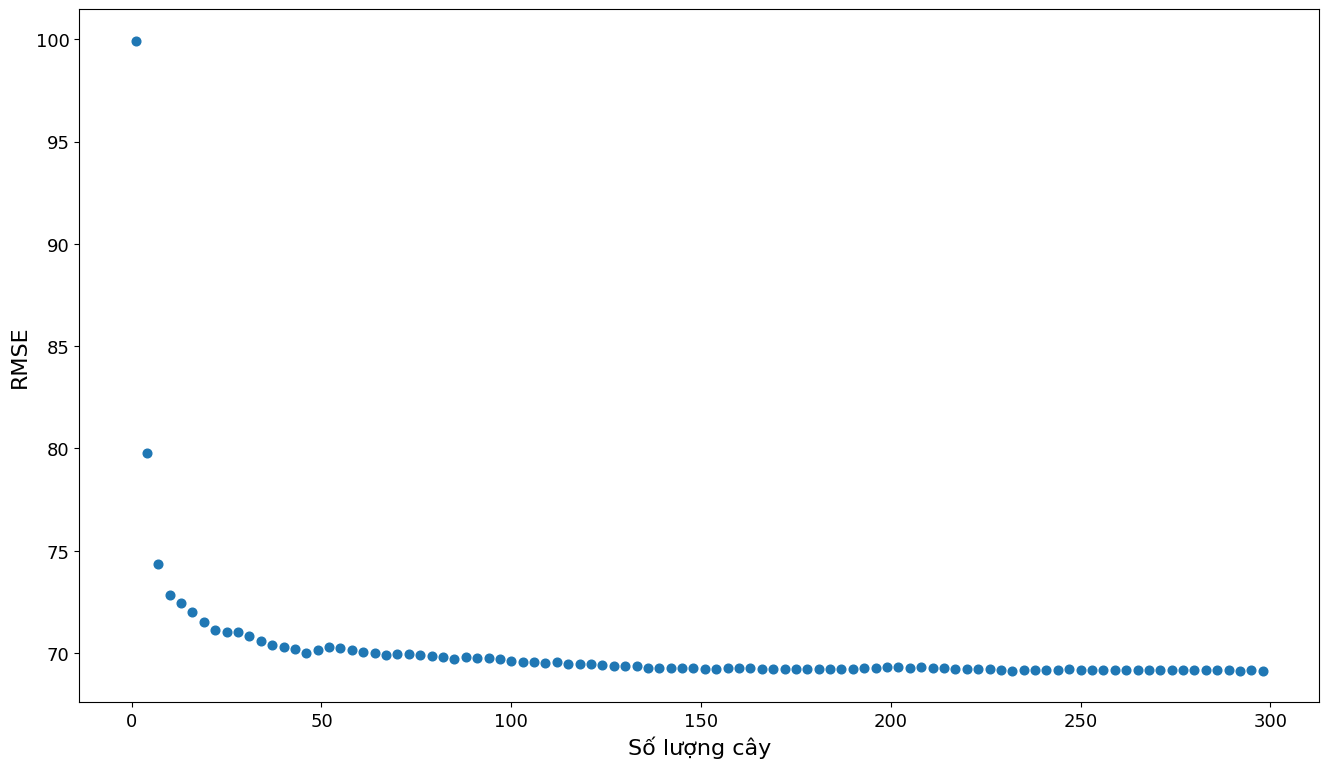

In [21]:
plt.figure(figsize=(16, 9))
plt.xlabel("Số lượng cây", fontsize=16)
plt.xticks(fontsize=13)
plt.ylabel("RMSE", fontsize=16)
plt.yticks(fontsize=13)

plt.scatter(n_trees, rmse_list, s=39)
plt.savefig("../fig/fig5.png", dpi=300, bbox_inches="tight")
plt.show()

# Max features

In [32]:
max_features_range = range(1, 25)
rmse_list = []

for mf in max_features_range:
    model = RandomForestRegressor(n_estimators=300, max_features=mf, n_jobs=-1, verbose=1, random_state=1337)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_list.append(rmse)
    print("   -> RMSE:", rmse, "with", mf, "features")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:    0.7s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    0.1s finished


   -> RMSE: 66.88584614513296 with 1 features


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:    1.2s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    0.1s finished


   -> RMSE: 66.55237379117678 with 2 features


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:    1.7s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    0.1s finished


...

   -> RMSE: 67.2829666081631 with 5 features


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:    3.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    0.1s finished


   -> RMSE: 67.55935721320333 with 6 features


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.4s


KeyboardInterrupt: 

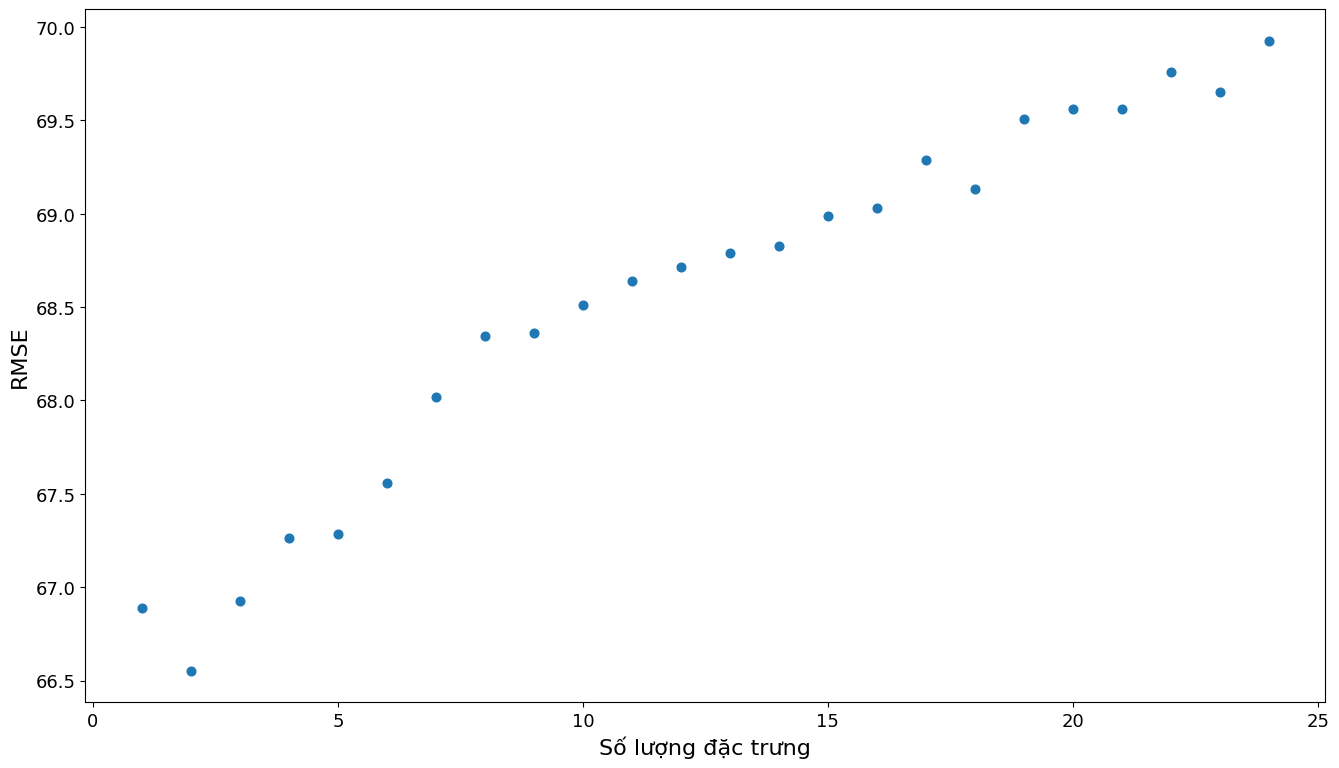

In [30]:
plt.figure(figsize=(16, 9))
plt.xlabel("Số lượng đặc trưng", fontsize=16)
plt.xticks(fontsize=13)
plt.ylabel("RMSE", fontsize=16)
plt.yticks(fontsize=13)

plt.scatter(max_features_range, rmse_list, s=39)
plt.savefig("../fig/fig6.png", dpi=300, bbox_inches="tight")
plt.show()